# Notebook 03 — Processes

## Overview

In the previous notebooks we built an ontology of *objects*: spatial objects like pizzas and their parts, qualities like spiciness, and quantities that measure them. But the world is not only made of objects — it is also made of **processes, events, and changes** that bring objects into existence, modify them, and destroy them.

A pizza is the outcome of a deliberate sequence: flour and water are mixed into dough, the dough ferments, sauce and toppings are assembled on a base, the whole is baked in a hot oven, and the baked result is sliced. Each step is a process — a temporally extended event whose participants may be created, changed, or consumed. Representing processes explicitly matters for provenance (knowing *how* an object came to be) and for identity (whether an object persists through a change or is destroyed and replaced by something new).

SULO provides a `Process` class and the `precedes` temporal relation as a foundation. This notebook extends that foundation with a small `pro` ontology that introduces process sub-types and a full participant role taxonomy, then models the full pizza-making pipeline from raw ingredients to sliced result.

## Learning Objectives

1. Extend SULO with a process-specific sub-ontology (`pro`) defining process sub-types (`DevelopmentalProcess`, `TransformationProcess`) and a participant role taxonomy
2. Model processes using `sulo:hasParticipant` with `some` restrictions to relate processes to the classes of objects that participate in them
3. Distinguish identity-preserving processes (`DevelopmentalProcess`) from identity-changing processes (`TransformationProcess`) and apply the correct type to each pizza-making step
4. Apply the role-reification pattern — `ConsumedRole`, `EmergingRole`, `AgentRole`, and others — to add semantic precision beyond flat participant descriptions
5. Chain processes in temporal order at the TBox level using `sulo:precedes` class-level axioms
6. Apply the full process modelling pattern independently to a new step in the pizza pipeline

## Getting started

The following cell loads SULO and the pizza ontology built in notebook 02, then creates the `pro` extension ontology that adds process sub-types and role classes used throughout this notebook.

In [1]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()  # RDF/XML
pizza = get_ontology("dist/pizza-02.owl").load()
pizza.imported_ontologies.append(sulo)

## Making the Pizza Dough

Pizza dough is made by combining `Flour`, `Water`, `Sugar`, `BakersYeast`, and `Salt` and working them together until a uniform, elastic mass forms. The ingredients are consumed as the new dough comes into existence — a `TransformationProcess`.

We first define the ingredient and output classes, then model the process using the PRO pattern introduced in the next section.

In [2]:
with pizza:
    class Flour(pizza.FoodMaterial):
        """A powder made from ground cereal grains, typically wheat, that provides the structural matrix of pizza dough through gluten formation."""
        label = [locstr("flour", "en")]

    class Water(pizza.FoodMaterial):
        """A liquid that hydrates flour proteins, enabling gluten development and yeast activity during dough formation."""
        label = [locstr("water", "en")]

    class Sugar(pizza.FoodMaterial):
        """A simple carbohydrate that serves as a nutrient source for yeast fermentation and contributes to browning during baking."""
        label = [locstr("sugar", "en")]
    
    class BakersYeast(pizza.FoodMaterial):
        """A leavening agent (Saccharomyces cerevisiae) that ferments sugars to produce carbon dioxide."""
        label = [locstr("baker's yeast", "en")]

    class Salt(pizza.FoodMaterial):
        """A mineral (sodium chloride) that strengthens gluten structure, regulates yeast activity, and enhances flavour in the dough."""
        label = [locstr("salt", "en")]

    class PizzaDough(pizza.FoodMaterial):
        """A cohesive elastic mass produced by combining and kneading flour, water, sugar, yeast, and salt; the structural foundation of a pizza."""
        label = [locstr("pizza dough", "en")]

    class Person(sulo.SpatialObject):
        """A human being, individual, or entity recognized as having conscious, moral, or legal capacities, such as reasoning, self-awareness, or rights"""
        label = [locstr("person", "en")]

In [3]:
# The simplest way to describe MakingThePizzaDough would be a flat hasParticipant pattern:
with pizza:
    class MakingThePizzaDough(sulo.Process):
        label = [locstr("making the pizza dough", "en")]
        is_a = [sulo.Process
                & sulo.hasParticipant.some(Flour)
                & sulo.hasParticipant.some(Water)
                & sulo.hasParticipant.some(Sugar)
                & sulo.hasParticipant.some(BakersYeast)
                & sulo.hasParticipant.some(Salt)
                & sulo.hasParticipant.some(PizzaDough)
                & sulo.hasParticipant.some(Person)
               ]

## The PRO Pattern: Specifying process participation roles

The class description for `MakingThePizzaDough` uses `hasParticipant` equally on all participants. This works but is semantically flat: the ontology cannot distinguish which participants are consumed as inputs and which emerge as outputs.

The **Process-Role-Object (PRO) ontology design pattern** solves this by introducing a lightweight intermediate entity — a *role* — that mediates between the process and each object participant. A role is a `sulo:Feature` that is `isFeatureOf` the entity playing it.

The pattern for each process participant links the process to the role to the object: `hasParticipant some (Role and isFeatureOf some Object)`

We define the following participant roles and process types in the `pro` ontology:

| Role class | Parent | Meaning |
|---|---|---|
| `AgentRole` | `sulo:Role` | The entity intentionally initiates and controls the process |
| `PatientRole` | `sulo:Role` | The entity undergoes the effects of the process |
| `ConsumedRole` | `PatientRole` | The entity ceases to exist during or by the process |
| `DevelopmentRole` | `PatientRole` | The entity persists but changes its qualities or sortal classification |
| `InstrumentRole` | `sulo:Role` | The entity mediates or enables the process; triggered by an agent |
| `LocationRole` | `sulo:Role` | The spatial object in which the process occurs |
| `PersistingRole` | `sulo:Role` | The entity persists unchanged through the process |
| `EmergingRole` | `sulo:Role` | The entity comes into existence as a new individual |

| Process class | Meaning |
|---|---|
| `DevelopmentalProcess` | A process that changes the composition or qualities of an entity while maintaining its identity |
| `TransformationProcess` | A process that creates or destroys entities |

In [4]:
base_iri = "https://w3id.org/ontostart/pro/"
pro = get_ontology(base_iri)

with pro:
    ## Participant Roles
    class AgentRole(sulo.Role):
        """A role played by an entity that intentionally initiates or controls the process, bearing volition and causal efficacy."""
        label = [locstr("agent role", "en")]

    class PatientRole(sulo.Role):
        """A role played by a participant that undergoes the effects of the process, experiencing change of state or causal affectedness."""
        label = [locstr("patient role", "en")]

    class InstrumentRole(sulo.Role):
        """A role played by an entity that mediates or enables a process causally without being an undergoer. Requires an agent."""
        label = [locstr("instrument role", "en")]

    class LocationRole(sulo.Role):
        """A role played by the spatial region in which the process occurs."""
        label = [locstr("location role", "en")]

    class PersistingRole(sulo.Role):
        """A participant that persists unchanged in both identity and sortal classification across the process."""
        label = [locstr("persisting role", "en")]

    class EmergingRole(sulo.Role):
        """A participant that comes into existence during the process and did not exist before."""
        label = [locstr("emerging role", "en")]

    class DevelopmentRole(PatientRole):
        """A participant that persists in their identity but undergoes changes in their composition or quality, potentially leading to a sortal type change."""
        label = [locstr("development role", "en")]

    class ConsumedRole(PatientRole):
        """A participant that exists before the process but ceases to exist during or by its completion. Its matter is not preserved as a traceable individual."""
        label = [locstr("consumed role", "en")]

    # Top-level roles are mutually disjoint; ConsumedRole and DevelopmentRole inherit
    # their disjointness constraints from PatientRole and need not appear here.
    AllDisjoint([AgentRole, PatientRole, InstrumentRole, LocationRole, PersistingRole, EmergingRole])

    class DevelopmentalProcess(sulo.Process):
        """A process that changes the composition or qualities of an entity while maintaining their identity."""
        label = [locstr("developmental process", "en")]

    class TransformationProcess(sulo.Process):
        """A process that creates or destroys entities."""
        label = [locstr("transformation process", "en")]

    AllDisjoint([DevelopmentalProcess, TransformationProcess])

os.makedirs("dist", exist_ok=True)
pro.save("dist/pro.owl", format="rdfxml")

pizza.imported_ontologies.append(pro)

In [5]:
with pizza:
    class Person(sulo.SpatialObject):
        """A human being"""
        label = [locstr("person", "en")]

    class BakerRole(pro.AgentRole):
        """The role of an individual who prepares and bakes flour-based foods."""
        label = [locstr("baker role", "en")]

# Remove the flat definition so the PRO version below starts clean
destroy_entity(MakingThePizzaDough)

with pizza:
    class MakingThePizzaDough(pro.TransformationProcess):
        """Dough-making with fine-grained participant roles.

        Ingredients play ConsumedRole — they cease to exist as the process completes.
        The resulting dough plays EmergingRole — it comes into being as a new individual.
        The baker plays BakerRole (AgentRole) — they intentionally initiate and control the process.
        """
        label = [locstr("making the pizza dough", "en")]
        is_a = [pro.TransformationProcess
                 # Ingredients: ConsumedRole (cease to exist during the process)
                 & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(Flour))
                 & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(Water))
                 & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(Sugar))
                 & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(BakersYeast))
                 & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(Salt))
                 # PizzaDough: EmergingRole (a new individual comes into being)
                 & sulo.hasParticipant.some(pro.EmergingRole & sulo.isFeatureOf.some(PizzaDough))
                 # The person that prepares the dough
                 & sulo.hasParticipant.some(BakerRole & sulo.isFeatureOf.some(Person))
                ]

# Verify axioms
result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])
print()
print("MakingThePizzaDough is_a:")
for axiom in MakingThePizzaDough.is_a:
    print(" ", axiom)

Ontology consistent: True
Inconsistent classes: []

MakingThePizzaDough is_a:
  pro.TransformationProcess
  pro.TransformationProcess & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-02.Flour)) & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-02.Water)) & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-02.Sugar)) & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-02.BakersYeast)) & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-02.Salt)) & sulo.hasParticipant.some(pro.EmergingRole & sulo.isFeatureOf.some(pizza-02.PizzaDough)) & sulo.hasParticipant.some(pizza-02.BakerRole & sulo.isFeatureOf.some(pizza-02.Person))


---

### YOUR TURN 1 — `KneadingTheDough`

After the ingredients are combined, the dough must be kneaded to develop gluten structure. Model `KneadingTheDough` as a `DevelopmentalProcess`:

- The dough persists as the same individual throughout — assign it `DevelopmentRole`
- A `Mixer` (define it as a new `sulo:SpatialObject` subclass) enables the process — assign it `InstrumentRole`
- Run the reasoner and verify consistency

In [6]:
# YOUR TURN 1 — your code here


## Proofing the Dough — a Developmental Process

When dough is proofed (fermented), yeast consumes sugars and produces CO₂, which causes the dough to expand. The texture becomes airy, the gluten relaxes, and a yeasty aroma develops.

Crucially, **the dough does not change its identity**: it is the same spatial object before and after proofing. Its qualities change, but it is still the same dough. This is why we model it as a `DevelopmentalProcess`, and why the participant plays a `DevelopmentRole` — persisting as the same individual while its qualitative profile shifts from an unproofed to a proofed state.

We capture the two stages using named roles and a quality sub-class:

| Stage | Role | Quality |
|---|---|---|
| Before proofing | `UnproofedDoughRole` | `DenseTexture` |
| After proofing | `ProofedDoughRole` | `AiryTexture` |

`ProofingTheDough` is modelled as a `DevelopmentalProcess` with two sub-processes chained by `precedes`: one in which the dough bears `UnproofedDoughRole` and `DenseTexture`, and one in which it bears `ProofedDoughRole` and `AiryTexture`. The `hasPart` + `precedes` nesting approximates the before/after temporal structure within a single OWL 2 class axiom.

In [7]:
with pizza:
    # Texture quality
    class DoughTexture(sulo.Quality):
        """A quality of pizza dough describing its internal structure and feel."""
        label = [locstr("dough texture", "en")]
    class DenseTexture(DoughTexture):
        """Compact, heavy texture characteristic of freshly mixed, unfermented dough."""
        label = [locstr("dense texture", "en")]
    class AiryTexture(DoughTexture):
        """Light, open-crumb texture produced by CO₂ bubbles from yeast fermentation."""
        label = [locstr("airy texture", "en")]
    AllDisjoint([DenseTexture, AiryTexture])

    class UnproofedDoughRole(sulo.Role):
        """An UnproofedDoughRole is a role that inheres in a dough object during a stage in which the dough 
        has not yet completed a proofing process resulting in significant volumetric expansion and aerated internal structure."""
        label = [locstr("unproofed dough role", "en")]

    class ProofedDoughRole(sulo.Role):
        """ A ProofedDoughRole is a role that inheres in a dough object after participation in a proofing process that 
        results in a sufficiently expanded and aerated dough structure."""
        label = [locstr("proofed dough role", "en")]
    AllDisjoint([UnproofedDoughRole, ProofedDoughRole])
        
    # Process
    class ProofingTheDough(pro.DevelopmentalProcess):
        """A developmental process in which PizzaDough undergoes fermentation.
        The dough transitions from UnproofedPizzaDough to ProofedPizzaDough:
        texture becomes airy, aroma becomes yeasty, and volume increases.
        The dough retains its identity — it is the same individual before and after."""
        label = [locstr("proofing the dough", "en")]
        is_a = [sulo.hasPart.some(
                    sulo.hasParticipant.some(UnproofedDoughRole & sulo.isFeatureOf.some(PizzaDough)) &
                    sulo.hasParticipant.some(DenseTexture & sulo.isFeatureOf.some(PizzaDough)))
                & sulo.precedes.some (
                    sulo.hasPart.some(
                        sulo.hasParticipant.some(ProofedDoughRole & sulo.isFeatureOf.some(PizzaDough)) &
                        sulo.hasParticipant.some(AiryTexture & sulo.isFeatureOf.some(PizzaDough)))
                )
                    ]

result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])
print()
print("ProofingTheDough is_a:")
for axiom in ProofingTheDough.is_a:
    print(" ", axiom)

Ontology consistent: True
Inconsistent classes: []

ProofingTheDough is_a:
  pro.DevelopmentalProcess
  sulo.hasPart.some(sulo.hasParticipant.some(pizza-02.UnproofedDoughRole & sulo.isFeatureOf.some(pizza-02.PizzaDough)) & sulo.hasParticipant.some(pizza-02.DenseTexture & sulo.isFeatureOf.some(pizza-02.PizzaDough))) & sulo.precedes.some(sulo.hasPart.some(sulo.hasParticipant.some(pizza-02.ProofedDoughRole & sulo.isFeatureOf.some(pizza-02.PizzaDough)) & sulo.hasParticipant.some(pizza-02.AiryTexture & sulo.isFeatureOf.some(pizza-02.PizzaDough))))


## Assembling the Pizza — a Transformation Process

After proofing, the baker flattens the dough and adds sauce, cheese, and toppings. This assembly step is a `TransformationProcess`: the pizza as a composite whole comes into existence as a new individual, while its ingredient parts persist within it.

The key ontological point is that **a new object comes into existence** while the input materials persist as its parts. The ingredients play `PersistingRole`; the pizza plays `EmergingRole`.

| Participant | Role |
|---|---|
| `PizzaDough` | `PersistingRole` — flattened base; retains identity as part of the assembly |
| `PizzaSauce` | `PersistingRole` — spread over the base |
| `Cheese` | `PersistingRole` — at least one variety |
| `PizzaTopping` | `PersistingRole` — optional additional toppings |
| `Pizza` | `EmergingRole` — the assembled whole comes into being |
| `Person` | `BakerRole` (sub-type of `AgentRole`) — directs the assembly |

In [8]:
with pizza:
    class AssemblingThePizza(pro.TransformationProcess):
        """A transformation process in which PizzaDough, PizzaSauce, Cheese, and toppings
        persist as parts of a new assembled pizza.
        Inputs retain identity; the pizza comes into being as a new composite whole."""
        label = [locstr("assembling the pizza", "en")]
        is_a = [
            sulo.hasParticipant.some(pro.PersistingRole & sulo.isFeatureOf.some(PizzaDough)),
            sulo.hasParticipant.some(pro.PersistingRole & sulo.isFeatureOf.some(pizza.PizzaSauce)),
            sulo.hasParticipant.some(pro.PersistingRole & sulo.isFeatureOf.some(pizza.Cheese)),
            sulo.hasParticipant.some(pro.PersistingRole & sulo.isFeatureOf.some(pizza.PizzaTopping)),
            sulo.hasParticipant.some(pro.EmergingRole & sulo.isFeatureOf.some(pizza.Pizza)),
            sulo.hasParticipant.some(BakerRole & sulo.isFeatureOf.some(Person)),
        ]

print("AssemblingThePizza is_a:", AssemblingThePizza.is_a)

AssemblingThePizza is_a: [pro.TransformationProcess, sulo.hasParticipant.some(pro.PersistingRole & sulo.isFeatureOf.some(pizza-02.PizzaDough)), sulo.hasParticipant.some(pro.PersistingRole & sulo.isFeatureOf.some(pizza-02.PizzaSauce)), sulo.hasParticipant.some(pro.PersistingRole & sulo.isFeatureOf.some(pizza-02.Cheese)), sulo.hasParticipant.some(pro.PersistingRole & sulo.isFeatureOf.some(owl.Thing)), sulo.hasParticipant.some(pro.EmergingRole & sulo.isFeatureOf.some(pizza-02.Pizza)), sulo.hasParticipant.some(pizza-02.BakerRole & sulo.isFeatureOf.some(pizza-02.Person))]


## Baking the Pizza — a Developmental Process

Baking involves two simultaneous changes, both of which **preserve the identity of their participants** while altering their sortal classification or qualities:

| Sub-process | Type | Participant | Role | Change |
|---|---|---|---|---|
| `DoughBaking` | `DevelopmentalProcess` | dough/crust individual | `DevelopmentRole` | sortal: `PizzaDough` → `PizzaCrust` |
| `CheeseMelting` | `DevelopmentalProcess` | cheese individual | `DevelopmentRole` | quality: solid → molten |

The dough and the crust are not two different individuals — they are the same spatial object at different stages of the baking process. The matter persists; only the sortal classification changes.

We model `BakingThePizza` as a `DevelopmentalProcess` composed of both sub-processes as parts.

In [9]:
with pizza:
    class DoughBaking(pro.DevelopmentalProcess):
        """The sub-process of baking in which the dough/crust individual changes its sortal
        classification from PizzaDough to PizzaCrust. The same individual persists throughout."""
        label = [locstr("dough baking", "en")]
        is_a = [
            sulo.hasParticipant.some(pro.DevelopmentRole & sulo.isFeatureOf.some(PizzaDough)),
            sulo.hasParticipant.some(pro.DevelopmentRole & sulo.isFeatureOf.some(pizza.PizzaCrust)),
        ]

    class CheeseMelting(pro.DevelopmentalProcess):
        """The sub-process of baking in which Cheese undergoes phase change (solid → molten).
        The cheese retains its identity as the same individual."""
        label = [locstr("cheese melting", "en")]
        is_a = [sulo.hasParticipant.some(pro.DevelopmentRole & sulo.isFeatureOf.some(pizza.Cheese))]

    class BakingThePizza(pro.DevelopmentalProcess):
        """The overall pizza baking process.
        Decomposes into DoughBaking and CheeseMelting, both identity-preserving."""
        label = [locstr("baking the pizza", "en")]
        is_a = [
            sulo.hasPart.some(DoughBaking),
            sulo.hasPart.some(CheeseMelting),
        ]

print("DoughBaking is_a: ", DoughBaking.is_a)
print("CheeseMelting is_a:", CheeseMelting.is_a)
print("BakingThePizza is_a:", BakingThePizza.is_a)

DoughBaking is_a:  [pro.DevelopmentalProcess, sulo.hasParticipant.some(pro.DevelopmentRole & sulo.isFeatureOf.some(pizza-02.PizzaDough)), sulo.hasParticipant.some(pro.DevelopmentRole & sulo.isFeatureOf.some(pizza-02.PizzaCrust))]
CheeseMelting is_a: [pro.DevelopmentalProcess, sulo.hasParticipant.some(pro.DevelopmentRole & sulo.isFeatureOf.some(pizza-02.Cheese))]
BakingThePizza is_a: [pro.DevelopmentalProcess, sulo.hasPart.some(pizza-02.DoughBaking), sulo.hasPart.some(pizza-02.CheeseMelting)]


## Slicing the Pizza — a Transformation Process

When a pizza is sliced, the whole pizza **ceases to exist** as a single unified object, and several `PizzaSlice` objects come into being. This is a `TransformationProcess`: the identity of the whole is destroyed, and new part-objects emerge in its place.

The pizza plays `ConsumedRole` — it ceases to exist as a unified individual; each slice plays `EmergingRole` — it comes into existence through division, inheriting matter from the original whole but not its identity.

In [10]:
with pizza:
    class PizzaSlice(pizza.FoodMaterial):
        """A portion of a baked pizza produced by slicing."""
        label = [locstr("pizza slice", "en")]

    class SlicingThePizza(pro.TransformationProcess):
        """A transformation process in which a whole Pizza ceases to exist
        and multiple PizzaSlice objects come into being."""
        label = [locstr("slicing the pizza", "en")]
        is_a = [
            sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza.Pizza)),
            sulo.hasParticipant.some(pro.EmergingRole & sulo.isFeatureOf.some(PizzaSlice)),
        ]

print("SlicingThePizza is_a:", SlicingThePizza.is_a)

SlicingThePizza is_a: [pro.TransformationProcess, sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-02.Pizza)), sulo.hasParticipant.some(pro.EmergingRole & sulo.isFeatureOf.some(pizza-02.PizzaSlice))]


## Temporal Ordering of Processes

The five pizza-making processes have a fixed sequential order. SULO provides the `precedes` object property (domain and range `Process`) to express that one process type systematically precedes another.

Adding these axioms at the class (TBox) level means: *every instance* of `MakingThePizzaDough` precedes *some instance* of `ProofingTheDough`, and so on down the chain.

```
MakingThePizzaDough → ProofingTheDough → AssemblingThePizza → BakingThePizza → SlicingThePizza
```

SULO also provides `atTime` (which links any entity to a `Time` individual) for absolute temporal anchoring when you need to assert specific timestamps on process instances.

In [11]:
with pizza:
    MakingThePizzaDough.is_a.append(sulo.precedes.some(ProofingTheDough))
    ProofingTheDough.is_a.append(sulo.precedes.some(AssemblingThePizza))
    AssemblingThePizza.is_a.append(sulo.precedes.some(BakingThePizza))
    BakingThePizza.is_a.append(sulo.precedes.some(SlicingThePizza))

# Verify the ordering axioms were added
for cls in [MakingThePizzaDough, ProofingTheDough, AssemblingThePizza, BakingThePizza]:
    ordering = [a for a in cls.is_a if hasattr(a, 'property') and a.property == sulo.precedes]
    print(f"{cls.name} precedes: {[str(a.value) for a in ordering]}")

MakingThePizzaDough precedes: ['pizza-02.ProofingTheDough']
ProofingTheDough precedes: ['pizza-02.AssemblingThePizza']
AssemblingThePizza precedes: ['pizza-02.BakingThePizza']
BakingThePizza precedes: ['pizza-02.SlicingThePizza']


Ontology is consistent. Inconsistent classes: 0
Saved pizza-03.owl


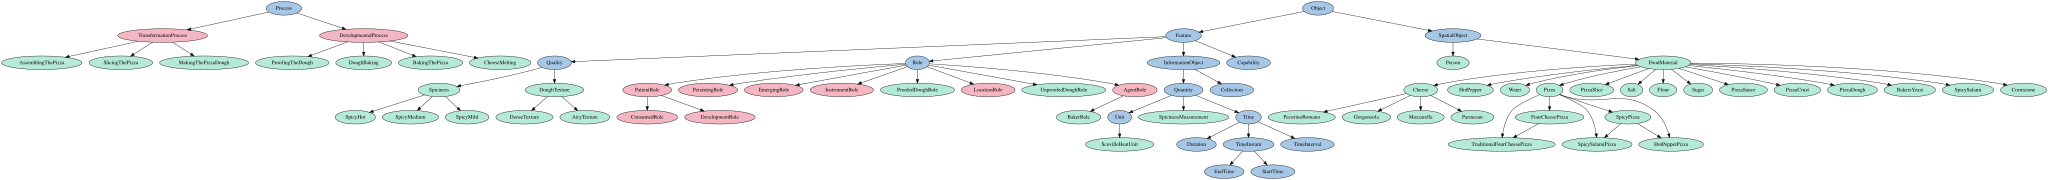

In [12]:
result = safe_call_reasoner(pizza)
if result["ok"]:
    n_inconsistent = len(result["inconsistent"])
    print(f"Ontology is consistent. Inconsistent classes: {n_inconsistent}")
else:
    print("Reasoner error:", result.get("error"))

import os
os.makedirs("dist", exist_ok=True)
pizza.save(file="dist/pizza-03.owl", format="rdfxml")
print("Saved pizza-03.owl")
display(get_color_tree([sulo, pro, pizza]))

---

### YOUR TURN 2 — Process classification

For each of the following food processes, decide whether it is a `DevelopmentalProcess` or a `TransformationProcess`, identify the key participant(s), and assign each an appropriate role from the `pro` taxonomy. Be prepared to justify your classification.

| Process | Classification | Key participant | Role |
|---|---|---|---|
| Grating a block of Parmesan into shreds | ? | ? | ? |
| Reducing tomato sauce (water evaporates, sauce thickens) | ? | ? | ? |
| Freezing a leftover pizza slice | ? | ? | ? |

Then pick **one** of the three processes and implement it using the PRO pattern. Define any new classes you need, chain it to an existing process in the pipeline using `precedes`, and run the reasoner to verify consistency.

In [13]:
# YOUR TURN 2 — your code here


---

## Summary

In this notebook we modelled the pizza-making pipeline as a sequence of typed processes, introducing the `pro` ontology for process sub-types and a participant role taxonomy.

### What we built

**Process sub-types** (mutually disjoint)

| Class | Meaning |
|---|---|
| `DevelopmentalProcess` | Entity persists; its qualities or sortal classification change |
| `TransformationProcess` | Entities are created or destroyed |

**Participant roles**

| Role | Parent | Meaning |
|---|---|---|
| `AgentRole` | `sulo:Role` | intentionally initiates and controls the process |
| `PatientRole` | `sulo:Role` | undergoes effects of the process |
| `ConsumedRole` | `PatientRole` | ceases to exist during or by the process |
| `DevelopmentRole` | `PatientRole` | persists while changing qualities or sortal classification |
| `InstrumentRole` | `sulo:Role` | mediates/enables the process; not an undergoer |
| `LocationRole` | `sulo:Role` | spatial region where the process occurs |
| `PersistingRole` | `sulo:Role` | persists unchanged in identity and classification |
| `EmergingRole` | `sulo:Role` | comes into existence as a new individual |

Top-level roles (`AgentRole`, `PatientRole`, `InstrumentRole`, `LocationRole`, `PersistingRole`, `EmergingRole`) are mutually disjoint. `ConsumedRole` and `DevelopmentRole` inherit their disjointness constraints from `PatientRole`.

**Pizza domain processes**

| Class | Process type | Participant roles |
|---|---|---|
| `MakingThePizzaDough` | `TransformationProcess` | `ConsumedRole` (ingredients), `EmergingRole` (dough), `BakerRole` (person) |
| `ProofingTheDough` | `DevelopmentalProcess` | `DevelopmentRole` (dough before/after via sub-process `hasPart`+`precedes`) |
| `AssemblingThePizza` | `TransformationProcess` | `PersistingRole` (ingredients), `EmergingRole` (pizza), `BakerRole` (person) |
| `DoughBaking` | `DevelopmentalProcess` | `DevelopmentRole` (same individual: `PizzaDough` → `PizzaCrust`) |
| `CheeseMelting` | `DevelopmentalProcess` | `DevelopmentRole` (cheese; solid → molten) |
| `BakingThePizza` | `DevelopmentalProcess` | `hasPart some DoughBaking`, `hasPart some CheeseMelting` |
| `SlicingThePizza` | `TransformationProcess` | `ConsumedRole` (pizza), `EmergingRole` (slices) |

### Key concepts

**Process identity and continuity.** The central modelling question for any process is whether its participants persist through the change (`DevelopmentalProcess`) or are created/destroyed (`TransformationProcess`). Getting this distinction right — as in `DoughBaking`, where the same individual merely changes its sortal classification — is foundational to correct identity tracking.

**`hasParticipant some` as the basic process axiom.** Using `sulo:hasParticipant.some(X)` at the class level expresses that every instance of the process has at least one participant of type `X`. This is the minimal, open-world-safe way to describe process participants.

**The PRO pattern.** Flat `hasParticipant some Flour` tells us an ingredient participates; `hasParticipant some (ConsumedRole and isFeatureOf some Flour)` additionally asserts the role it plays — here, that it is consumed. The pattern applies uniformly across all process types: choose the role that best describes each participant's fate, then link process → role → object.

**TBox-level temporal ordering.** Using `precedes.some(NextProcess)` as a `SubClassOf` axiom means the ordering constraint holds universally for all process instances.

### What comes next

Notebook 04 covers **information objects** — representing recipes, labels, and other information artefacts that describe or specify the processes and objects modelled here.